# Modelos Transformers — Classificação AI vs Humano

Notebook para treinar e testar modelos baseados em Transformers:
1. **TransformerClassifier** — Transformer manual (embedding + multi-head attention)
2. **BERTClassifier** — Fine-tuning de BERT pré-treinado

- **Treino**: `dataset_limpo.csv` (split 80/20 train/val)
- **Teste**: `dataset-exemplos.csv`

## 1. Setup

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, os.path.join(os.getcwd(), "..", "models"))

from transformers_models import (
    TransformerClassifier,
    BERTClassifier,
    TransformerSequenceDataset,
    BERTDataset,
    train,
    evaluate,
    predict,
)
from pytorch_models.dataset import clean_text, build_vocab

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Setup completo!")

/home/luiscunha/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 1050 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/luiscunha/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/luiscunha/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:435: UserWarning: 
NVIDIA GeForce GTX 1050 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the NVIDIA GeForce GTX 1050 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_ca

[pytorch_models] Using device: cpu
[transformers_models] Using device: cpu
Setup completo!


## 2. Carregamento de Dados

In [4]:
# Carregar dataset de treino 
df_train = pd.read_csv("../data/dataset_limpo.csv", sep=";")
print(f"Dataset treino: {df_train.shape}")
print(df_train["Label"].value_counts())

# Carregar dataset de teste 
df_test = pd.read_csv("../data/dataset-exemplos.csv", sep=";")
print(f"\nDataset teste: {df_test.shape}")
print(df_test["Label"].value_counts())

Dataset treino: (4995, 2)
Label
Human        999
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Dataset teste: (125, 3)
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64


In [5]:
# Label encoding
CLASS_LABELS = sorted(df_train["Label"].unique())
label2idx = {label: idx for idx, label in enumerate(CLASS_LABELS)}
idx2label = {idx: label for label, idx in label2idx.items()}

print(f"Classes: {CLASS_LABELS}")
print(f"Mapping: {label2idx}")

# Textos e labels
train_texts = df_train["Text"].tolist()
train_labels = [label2idx[l] for l in df_train["Label"]]

test_texts = df_test["Text"].tolist()
test_labels = [label2idx[l] for l in df_test["Label"]]

Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
Mapping: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}


---
## 3. TransformerClassifier (Manual)

### 3.1. Preparação dos dados

In [18]:
# Hiperparâmetros
MAX_WORDS = 10000
MAX_LEN = 200
BATCH_SIZE = 64
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1
EPOCHS_TRANSFORMER = 5
LR_TRANSFORMER = 0.001

# Limpar textos e construir vocabulário
clean_train_texts = [clean_text(t) for t in train_texts]
word_index = build_vocab(clean_train_texts, MAX_WORDS)
print(f"Vocabulário: {len(word_index)} palavras")

# Dataset completo de treino
full_train_dataset = TransformerSequenceDataset(
    train_texts, train_labels, word_index, MAX_LEN
)

# Split 80/20 train/val
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

# Dataset de teste
test_dataset = TransformerSequenceDataset(
    test_texts, test_labels, word_index, MAX_LEN
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Vocabulário: 10000 palavras
Train: 3996 | Val: 999 | Test: 125


### 3.2. Treino

In [22]:
# Criar modelo
transformer_model = TransformerClassifier(
    vocab_size=MAX_WORDS + 2,  # +2 para PAD(0) e UNK(1)
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    n_classes=len(CLASS_LABELS),
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"TransformerClassifier — Parâmetros: {total_params:,}")

# Treinar
history_transformer = train(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_TRANSFORMER,
    lr=LR_TRANSFORMER,
    patience=10,
)

TransformerClassifier — Parâmetros: 1,571,717
Epoch 1/5 | train_loss: 0.6189 | train_acc: 0.7725 | val_loss: 0.6801 | val_acc: 0.7628
Epoch 2/5 | train_loss: 0.4791 | train_acc: 0.8313 | val_loss: 0.6231 | val_acc: 0.7658
Epoch 3/5 | train_loss: 0.3375 | train_acc: 0.8839 | val_loss: 0.5429 | val_acc: 0.8098
Epoch 4/5 | train_loss: 0.2224 | train_acc: 0.9277 | val_loss: 0.5043 | val_acc: 0.8268
Epoch 5/5 | train_loss: 0.1373 | train_acc: 0.9645 | val_loss: 0.4681 | val_acc: 0.8478


### 3.3. Curvas de Treino

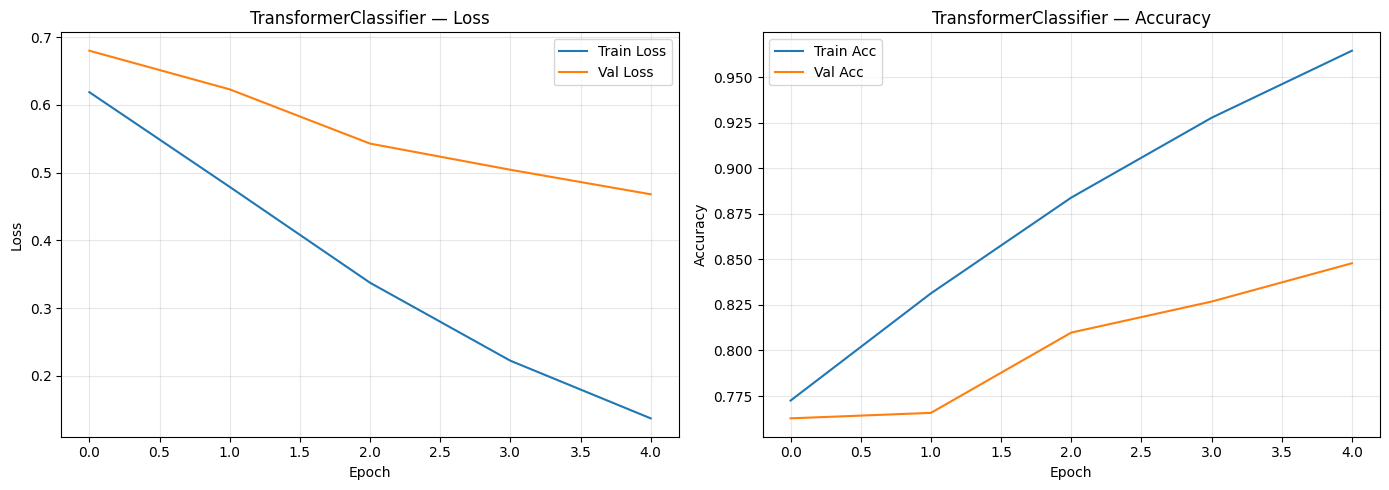

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_transformer["train_loss"], label="Train Loss")
axes[0].plot(history_transformer["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("TransformerClassifier — Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_transformer["train_acc"], label="Train Acc")
axes[1].plot(history_transformer["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("TransformerClassifier — Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4. Avaliação no Test Set

TransformerClassifier — Test Loss: 1.8698 | Test Acc: 0.5120

Classification Report:
              precision    recall  f1-score   support

   Anthropic       0.38      0.35      0.36        23
      Google       0.39      0.44      0.41        16
       Human       0.66      0.73      0.69        52
        Meta       0.70      0.41      0.52        17
      OpenAI       0.22      0.24      0.23        17

    accuracy                           0.51       125
   macro avg       0.47      0.43      0.44       125
weighted avg       0.52      0.51      0.51       125



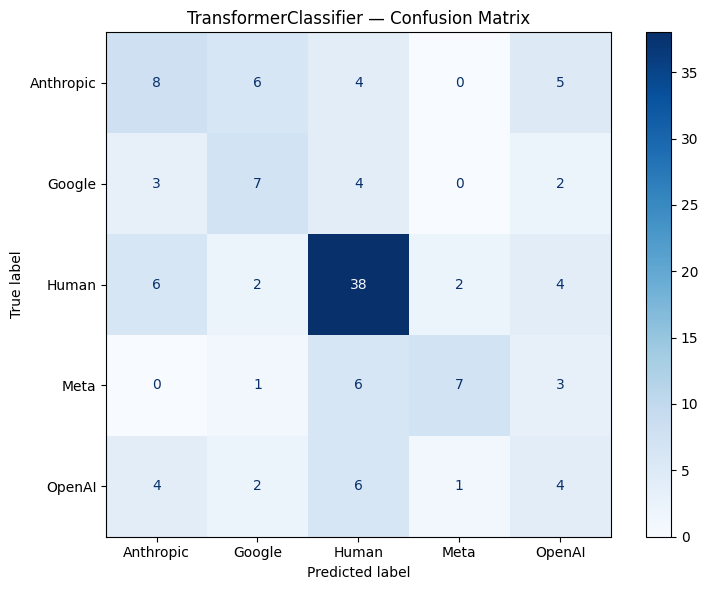

In [24]:
# Avaliação
test_loss, test_acc = evaluate(transformer_model, test_loader)
print(f"TransformerClassifier — Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

# Predições
y_pred_transformer = predict(transformer_model, test_loader).numpy()
y_true = np.array(test_labels)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_transformer, target_names=CLASS_LABELS))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_transformer)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("TransformerClassifier — Confusion Matrix")
plt.tight_layout()
plt.show()

---
## 4. BERTClassifier (Fine-tuning)

### 4.1. Preparação dos dados

In [25]:
from transformers import BertTokenizer

# Hiperparâmetros BERT
BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LEN = 128
BERT_BATCH_SIZE = 16
EPOCHS_BERT = 3
LR_BERT = 2e-5
BERT_DROPOUT = 0.3

# Tokenizer
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print(f"Tokenizer carregado: {BERT_MODEL_NAME}")

# Dataset completo de treino
full_bert_train = BERTDataset(train_texts, train_labels, tokenizer, BERT_MAX_LEN)

# Split 80/20
bert_train_size = int(0.8 * len(full_bert_train))
bert_val_size = len(full_bert_train) - bert_train_size
bert_train_dataset, bert_val_dataset = random_split(
    full_bert_train,
    [bert_train_size, bert_val_size],
    generator=torch.Generator().manual_seed(SEED),
)

# Dataset de teste
bert_test_dataset = BERTDataset(test_texts, test_labels, tokenizer, BERT_MAX_LEN)

# DataLoaders
bert_train_loader = DataLoader(bert_train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=BERT_BATCH_SIZE)
bert_test_loader = DataLoader(bert_test_dataset, batch_size=BERT_BATCH_SIZE)

print(f"Train: {len(bert_train_dataset)} | Val: {len(bert_val_dataset)} | Test: {len(bert_test_dataset)}")

Tokenizer carregado: bert-base-uncased
Train: 3996 | Val: 999 | Test: 125


### 4.2. Treino

In [26]:
# Criar modelo
bert_model = BERTClassifier(
    model_name=BERT_MODEL_NAME,
    n_classes=len(CLASS_LABELS),
    dropout=BERT_DROPOUT,
    freeze_bert=False,
)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"BERTClassifier — Total: {total_params:,} | Treináveis: {trainable_params:,}")

# Treinar
history_bert = train(
    model=bert_model,
    train_loader=bert_train_loader,
    val_loader=bert_val_loader,
    epochs=EPOCHS_BERT,
    lr=LR_BERT,
    patience=3,
    weight_decay=1e-2,
)

BERTClassifier — Total: 109,486,085 | Treináveis: 109,486,085


KeyboardInterrupt: 

### 4.3. Curvas de Treino

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_bert["train_loss"], label="Train Loss")
axes[0].plot(history_bert["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("BERTClassifier — Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_bert["train_acc"], label="Train Acc")
axes[1].plot(history_bert["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("BERTClassifier — Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4. Avaliação no Test Set

In [ ]:
# Avaliação
bert_test_loss, bert_test_acc = evaluate(bert_model, bert_test_loader)
print(f"BERTClassifier — Test Loss: {bert_test_loss:.4f} | Test Acc: {bert_test_acc:.4f}")

# Predições
y_pred_bert = predict(bert_model, bert_test_loader).numpy()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_bert, target_names=CLASS_LABELS))

# Confusion Matrix
cm_bert = confusion_matrix(y_true, y_pred_bert)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(8, 6))
disp_bert.plot(ax=ax, cmap="Greens", values_format="d")
ax.set_title("BERTClassifier — Confusion Matrix")
plt.tight_layout()
plt.show()

---
## 5. Comparação de Resultados

In [ ]:
# Tabela comparativa
results = pd.DataFrame({
    "Modelo": ["TransformerClassifier", "BERTClassifier"],
    "Test Loss": [test_loss, bert_test_loss],
    "Test Accuracy": [test_acc, bert_test_acc],
})
print("\n=== Comparação de Resultados ===")
print(results.to_string(index=False))

In [ ]:
# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ["TransformerClassifier", "BERTClassifier"]
colors = ["#4A90D9", "#50C878"]

# Test Accuracy
axes[0].bar(models, [test_acc, bert_test_acc], color=colors, edgecolor="black")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0, 1)
for i, v in enumerate([test_acc, bert_test_acc]):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Test Loss
axes[1].bar(models, [test_loss, bert_test_loss], color=colors, edgecolor="black")
axes[1].set_ylabel("Loss")
axes[1].set_title("Test Loss")
for i, v in enumerate([test_loss, bert_test_loss]):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Comparação de Modelos Transformers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()